# **Predicting Price with Size**

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression #Build our Model
from sklearn.metrics import mean_absolute_error #Evaluate our Model
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

# Prepare Data

## Import

**Task1:** Write a function named wrangle that takes a file path as an argument and returns a DataFrame.

In [2]:
def wrangle(filepath):
    #Read CSV file into DaraFrame
    df = pd.read_csv(filepath)

    #Subset to properties in "Capital Fedaral"
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    #Subset to "apartment"
    mask_apt = df["property_type"] == "apartment"
    #Subset to properties where "price_aprox_usd" <  400,000
    mask_price = df["price_aprox_usd"] < 400_000
    #Subset
    df = df[mask_ba & mask_apt & mask_price]

    #Remove outliers by "surface_covered_in_m2"
    low, high  = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area ]
    
    return df

**Task2:** Use your wrangle function to create a DataFrame df from the CSV file data/buenos-aires-real-estate-1.csv.

In [3]:
df = wrangle("data/buenos-aires-real-estate-1.csv")
print("df shape", df.shape)
df.head()


df shape (1343, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...


**Task3:** Add to your wrangle function so that the DataFrame it returns only includes apartments in Buenos Aires ("Capital Federal") that cost less than $400,000 USD. Then recreate df from data/buenos-aires-real-estate-1.csv by re-running the cells above

In [4]:
mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
df[mask_ba].head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...


In [5]:
#mask_apt = 
df["property_type"].unique()
#== "apartment"
#mask_apt.head()

<StringArray>
['apartment']
Length: 1, dtype: str

In [6]:
mask_price = df["price_aprox_usd"] < 400_000
mask_price.head()

4     True
9     True
29    True
40    True
41    True
Name: price_aprox_usd, dtype: bool

## Explore

**Task4:** Create a histogram of "surface_covered_in_m2". Make sure that the x-axis has the label "Area [sq meters]" and the plot has the title "Distribution of Apartment Sizes"

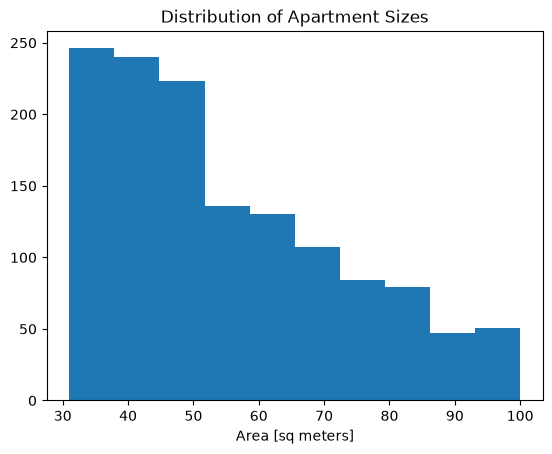

In [7]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes");

**Task5:** Calculate the summary statistics for df using the describe method

In [8]:
df.describe()["surface_covered_in_m2"]

count    1343.000000
mean       55.076694
std        18.160427
min        31.000000
25%        40.000000
50%        50.000000
75%        68.500000
max       100.000000
Name: surface_covered_in_m2, dtype: float64

**Task6:** Add to your wrangle function so that it removes observations that are outliers in the "surface_covered_in_m2" column. Specifically, all observations should fall between the 0.1 and 0.9 quantiles for "surface_covered_in_m2"

In [9]:
low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
mask_area = df["surface_covered_in_m2"].between(low, high)
mask_area.head()


4     True
9     True
29    True
40    True
41    True
Name: surface_covered_in_m2, dtype: bool

**Task7:** Create a scatter plot that shows price ("price_aprox_usd") vs area ("surface_covered_in_m2") in our dataset. Make sure to label your x-axis "Area [sq meters]" and your y-axis "Price [USD]".

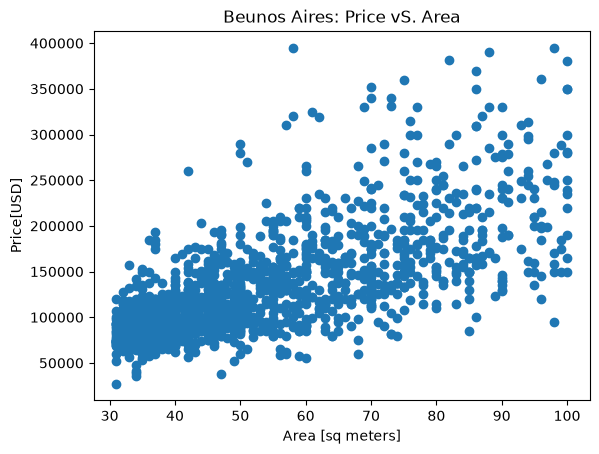

In [10]:

plt.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price[USD]")
plt.title("Beunos Aires: Price vS. Area");

## Split

**Task8:** Create the feature matrix named X_train, which you'll use to train your model. It should contain one feature only: ["surface_covered_in_m2"]. Remember that your feature matrix should always be two-dimensional.

In [11]:
features = ["surface_covered_in_m2"]
X_train = df[features]

**Task9:** Create the target vector named y_train, which you'll use to train your model. Your target should be "price_aprox_usd". Remember that, in most cases, your target vector should be one-dimensional.

In [12]:
target = "price_aprox_usd"
y_train = df[target]
y_train.shape

(1343,)

In [13]:
#Check your work
assert y_train.shape == (1343, )

# Build Model

## Baseline

**Task10:** Calculate the mean of your target vector y_train and assign it to the variable y_mean.



In [14]:
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

**Task11:** Create a list named y_pred_baseline that contains the value of y_mean repeated so that it's the same length at y

In [15]:
y_pred_baseline = [y_mean] * len(y_train)
len(y_pred_baseline) == len(y_train)

True

**Task12:** Add a line to the plot below that shows the relationship between the observations `X_train` and our dumb model's predictions `y_pred_baseline`. Be sure that the line color is orange, and that it has the label `"Baseline Model"`.

/tmp/ipykernel_17847/1297266310.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


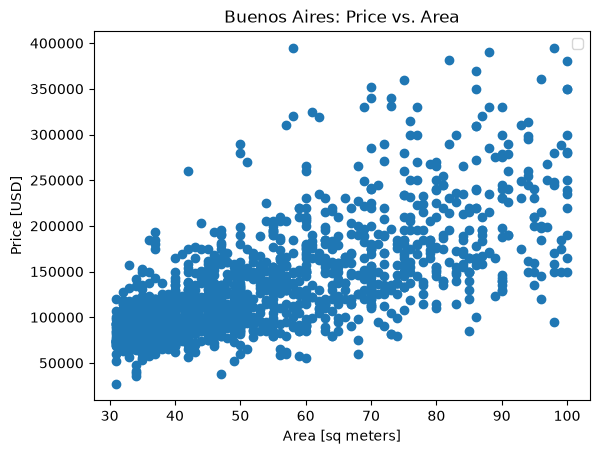

In [16]:
plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

**Task13:** Calculate the baseline mean absolute error for your predictions in y_pred_baseline as compared to the true targets in y.



In [17]:
mea_baseline = mean_absolute_error(y_train, y_pred_baseline)
print("Mean apt price:", round(y_mean, 2))
print("Baseline MAE:", round(mea_baseline))

Mean apt price: 135527.84
Baseline MAE: 45199


## Iterate

**Task14:** Instantiate a LinearRegression model named model.

In [18]:
model = LinearRegression()

In [19]:
#Check your Work
assert isinstance(model, LinearRegression)

**Task15:** Fit your model to the data, X_train and y_train.

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2253.12]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['surface_covered_in_m2']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.143e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [21]:
#Check your work
check_is_fitted(model)

## Evaluate

**Task16:** Using your model's predict method, create a list of predictions for the observations in your feature matrix X_train. Name this array y_pred_training.



In [22]:
y_pred_training = model.predict(X_train)
y_pred_training [:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [23]:
assert(
    len(y_pred_training ) == 1343
), f"There should be 1343 predictions in `y_pred_training`, not {len(y_pred_training)}"

**Task17:** Calculate your training mean absolute error for your predictions in y_pred_training as compared to the true targets in y_train.



In [24]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


**Task18:** Run the code below to import your test data buenos-aires-test-features.csv into a DataFrame and generate a Series of predictions using your model.

In [25]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    117330.058901
1    135355.037823
2     88039.468152
3     88039.468152
4    106064.447074
dtype: float64

## Communicate Results

**Task19:** Extract the intercept from your model, and assign it to the variable intercept.

In [26]:
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)
assert any([isinstance(intercept, int), isinstance(intercept, float)])

Model Intercept: 11433.31


**Task20:** Extract the coefficient associated "surface_covered_in_m2" in your model, and assign it to the variable coefficient.



In [27]:
coefficient = round(model.coef_[0], 2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)
assert any([isinstance(coefficient, int), isinstance(coefficient, float)])

Model coefficient for "surface_covered_in_m2": 2253.12


**Task21:** Complete the code below and run the cell to print the equation that your model has determined for predicting apartment price based on size.

In [28]:
print(f"apt_price = {intercept} + {coefficient} * surface_covered")

apt_price = 11433.31 + 2253.12 * surface_covered


**Task22:** Add a line to the plot below that shows the relationship between the observations in X_train and your model's predictions y_pred_training. Be sure that the line color is red, and that it has the label "Linear Model".



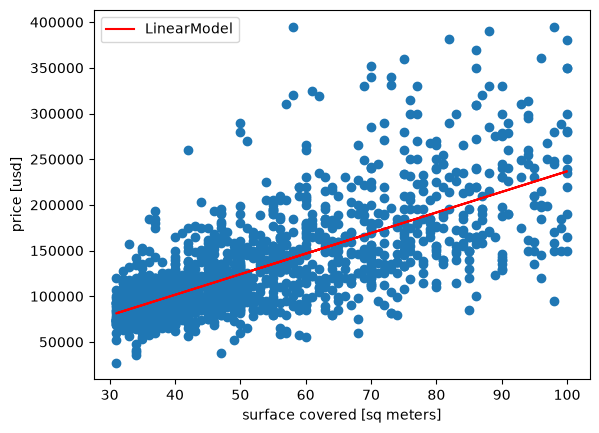

In [29]:
plt.plot(X_train.values, model.predict(X_train), color="red", label="LinearModel")
plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();